In [1]:
import numpy as np
import pandas as pd
from datetime import datetime as dt
from openbb import obb

import os

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

import OpenBBConvenienceFunctions as obb_cf
import PlottingFunctions as plot_func

from sklearn.preprocessing import StandardScaler

In [2]:
from API_Keys import FMP_API
from File_Paths import raw_data_filepath

In [3]:
start = '2010-01-01'
end = '2025-12-31'

In [4]:
date_list = pd.date_range(start=start, end=end, freq='B').strftime("%Y-%m-%d").to_list()

### S&P Returns

#### Raw data download

In [27]:
# sp500 = obb_cf.get_index_price_data('^GSPC', start=start, end=end, provider='yfinance')

In [28]:
# sp500.to_parquet(os.path.join(raw_data_filepath, r"SP500_price_data.parquet"))

#### Raw data exploration

In [29]:
sp500 = obb_cf.read_file(raw_data_filepath, r"SP500_price_data.parquet")

In [30]:
sp500 = obb_cf.append_returns(sp500, 'close')

In [31]:
sp500

,open,high,low,close,volume,simple_return,log_return
date,,,,,,,
2010-01-06,1135.709961,1139.189941,1133.949951,1137.140015,4972660000,0.000546,0.000545
2010-01-07,1136.270020,1142.459961,1131.319946,1141.689941,5270680000,0.004001,0.003993
2010-01-08,1140.520020,1145.390015,1136.219971,1144.979980,4389590000,0.002882,0.002878
2010-01-11,1145.959961,1149.739990,1142.020020,1146.979980,4255780000,0.001747,0.001745
2010-01-12,1143.810059,1143.810059,1131.770020,1136.219971,4716160000,-0.009381,-0.009425
...,...,...,...,...,...,...,...
2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,0.003221,0.003216
2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,2586550000,-0.000304,-0.000304
2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,3541750000,-0.003492,-0.003498


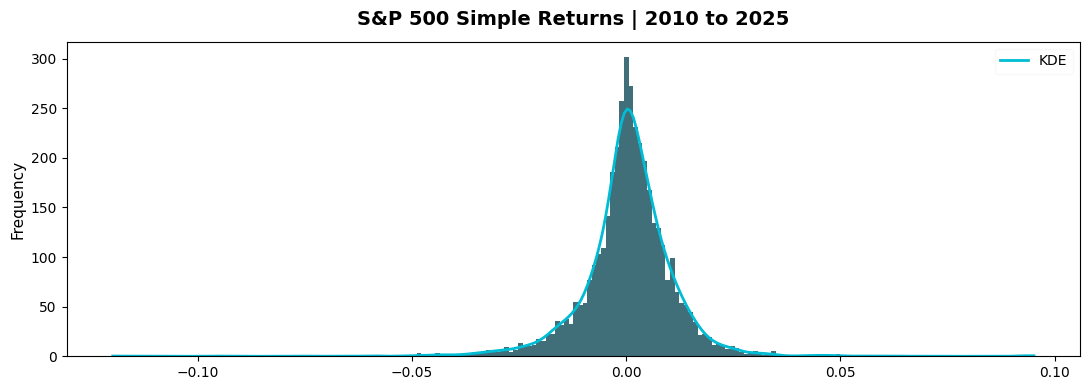

In [25]:
plot_func.plot_histogram(data=sp500[['simple_return']],
                         bins=200,
                         title="S&P 500 Simple Returns | 2010 to 2025", 
                         dark=False,
                         figsize=(11,4));

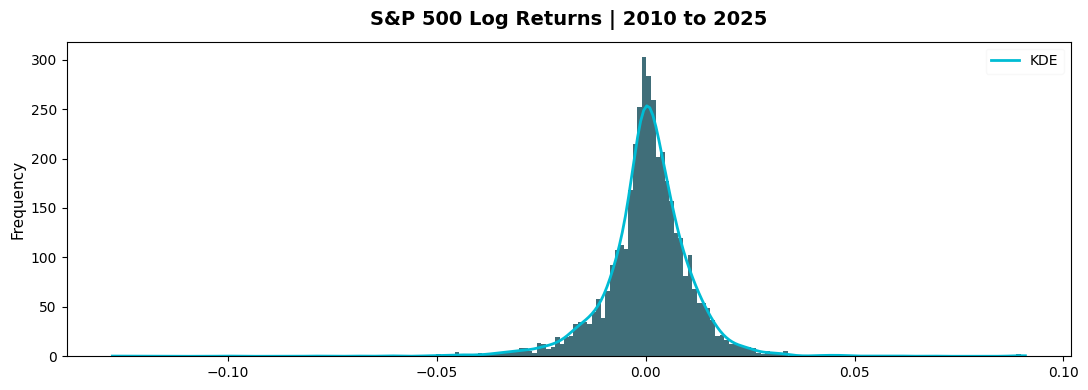

In [32]:
plot_func.plot_histogram(data=sp500[['log_return']],
                         bins=200,
                         title="S&P 500 Log Returns | 2010 to 2025", 
                         dark=False,
                         figsize=(11,4));

In [35]:
sp500.index = pd.to_datetime(sp500.index)

In [38]:
# Monthly volatility (annualised)

sp500['forward_vol_1m'] = sp500['simple_return'].shift(-1).rolling(21).std().shift(-20) * np.sqrt(252)

In [40]:
sp500

,open,high,low,close,volume,simple_return,log_return,forward_vol_1m
date,,,,,,,,
2010-01-06,1135.709961,1139.189941,1133.949951,1137.140015,4972660000,0.000546,0.000545,0.191684
2010-01-07,1136.270020,1142.459961,1131.319946,1141.689941,5270680000,0.004001,0.003993,0.190948
2010-01-08,1140.520020,1145.390015,1136.219971,1144.979980,4389590000,0.002882,0.002878,0.198394
2010-01-11,1145.959961,1149.739990,1142.020020,1146.979980,4255780000,0.001747,0.001745,0.197641
2010-01-12,1143.810059,1143.810059,1131.770020,1136.219971,4716160000,-0.009381,-0.009425,0.201262
...,...,...,...,...,...,...,...,...
2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,0.003221,0.003216,NaN
2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,2586550000,-0.000304,-0.000304,NaN
2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,3541750000,-0.003492,-0.003498,NaN


### VIX

In [13]:
vix_result = obb_cf.get_index_price_data('VIX', start=start, end=end, provider='cboe')
vix_result

,open,high,low,close
date,,,,
2010-01-04,21.68,21.68,20.03,20.04
2010-01-05,20.05,20.13,19.34,19.35
2010-01-06,19.59,19.68,18.77,19.16
2010-01-07,19.68,19.71,18.70,19.06
2010-01-08,19.27,19.27,18.11,18.13
...,...,...,...,...
2025-12-24,14.09,14.16,13.38,13.47
2025-12-26,14.12,14.29,13.52,13.60
2025-12-29,14.69,15.08,13.99,14.20


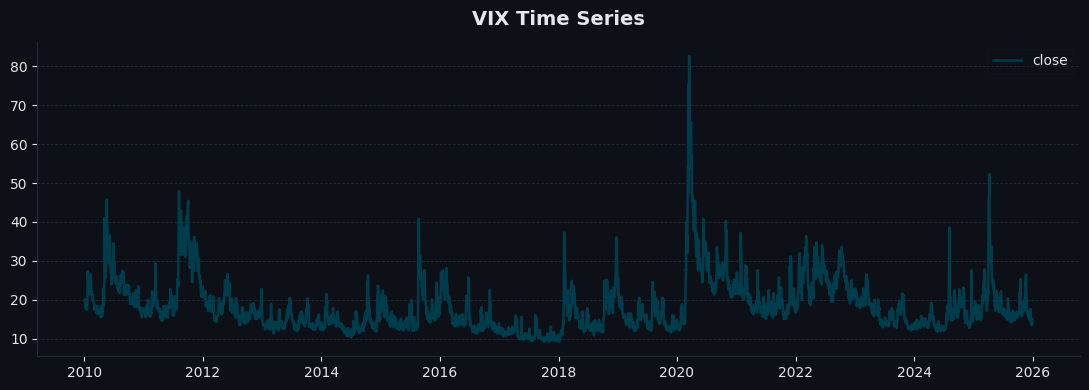

In [15]:
plot_func.plot_line(vix_result[['close']], title="VIX Time Series", figsize=(11,4));

In [17]:
vix_result.index = pd.to_datetime(vix_result.index)

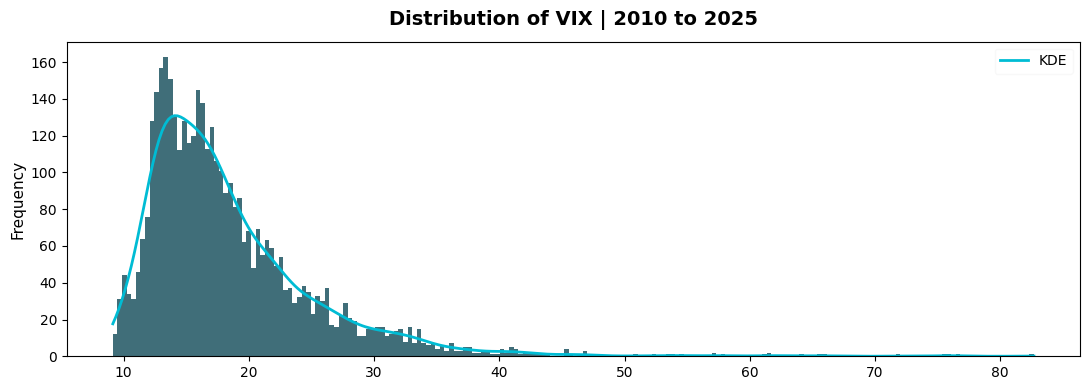

In [19]:
plot_func.plot_histogram(vix_result[['close']], bins=200, title="Distribution of VIX | 2010 to 2025",
                         figsize=(11,4), dark=False, kde=True);

In [21]:
# Appending returns (changes) column
vix_result = obb_cf.append_returns(vix_result, 'close')

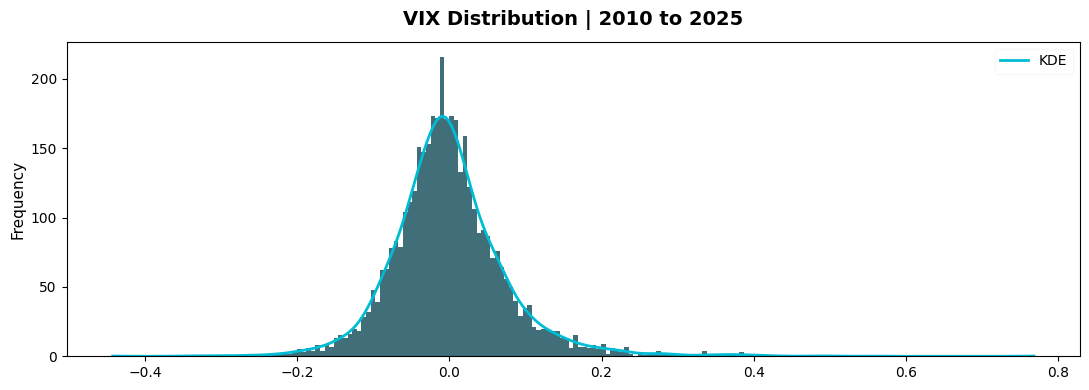

In [22]:
plot_func.plot_histogram(vix_result[['log_return']], bins=200, figsize=(11,4), dark=False, title="VIX Distribution | 2010 to 2025");

### FUTURES CURVE

#### Raw data download

In [ ]:
# vx_curve_df = obb_cf.get_futures_curve_data(date_list)

In [7]:
vx_curve_df

,expiration,price,symbol,DTE
date,,,,
2010-01-04,2010-02-01,24.90,VX2,28
2010-01-04,2010-03-01,25.30,VX3,56
2010-01-04,2010-04-01,25.75,VX4,87
2010-01-04,2010-05-01,25.75,VX5,117
2010-01-04,2010-06-01,25.75,VX6,148
...,...,...,...,...
2025-12-17,2026-04-01,21.05,VX5,105
2025-12-17,2026-05-01,21.35,VX6,135
2025-12-17,2026-06-01,21.55,VX7,166


In [ ]:
# vx_curve_df.to_parquet(os.path.join(raw_data_filepath, r"FuturesCurve.parquet"), engine="pyarrow")

#### Data Exploration

In [7]:
vx_curve_df = obb_cf.read_file(file_path=raw_data_filepath, file_name=r"FuturesCurve.parquet")

In [8]:
type(vx_curve_df.index)

pandas.DatetimeIndex

In [9]:
vx_curve_df.dtypes

expiration    datetime64[us]
price                float64
symbol                   str
DTE                    int64
dtype: object

In [10]:
vx_curve_df

,expiration,price,symbol,DTE
date,,,,
2010-01-04,2010-02-01,24.90,VX2,28
2010-01-04,2010-03-01,25.30,VX3,56
2010-01-04,2010-04-01,25.75,VX4,87
2010-01-04,2010-05-01,25.75,VX5,117
2010-01-04,2010-06-01,25.75,VX6,148
...,...,...,...,...
2025-12-17,2026-04-01,21.05,VX5,105
2025-12-17,2026-05-01,21.35,VX6,135
2025-12-17,2026-06-01,21.55,VX7,166


In [11]:
# Use plot_futures_curve to plot futures curve across different degrees of polynomials
# 
# Group by date and add columns showing slope, curvature, and (potentially) the 'twist' of the curve (i.e. if its an 'S' shape) 

# Check its relationship with forward volatility

In [12]:
unique_dates = vx_curve_df.index.unique()
random_numbers = np.random.randint(0, len(unique_dates), [1,5]).tolist()[0]
random_dates = [unique_dates[i].strftime('%Y-%m-%d') for i in random_numbers]
random_dates.sort()
random_dates

['2015-09-22', '2016-01-13', '2022-10-03', '2024-07-08', '2025-01-13']

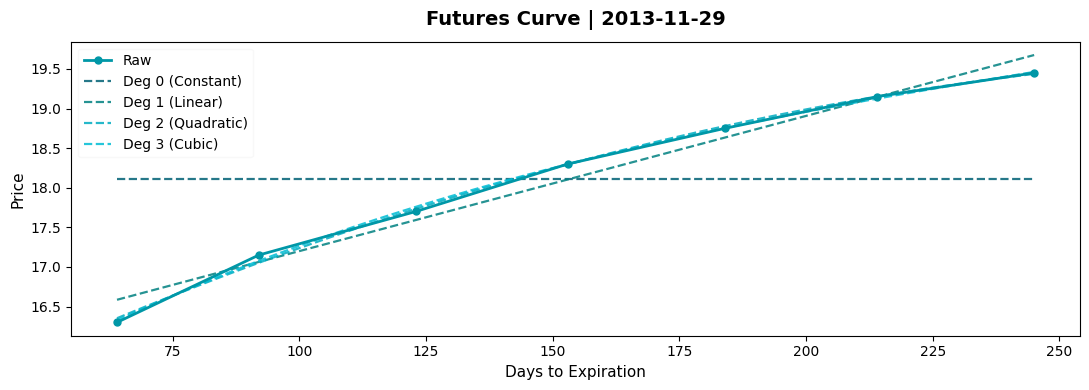

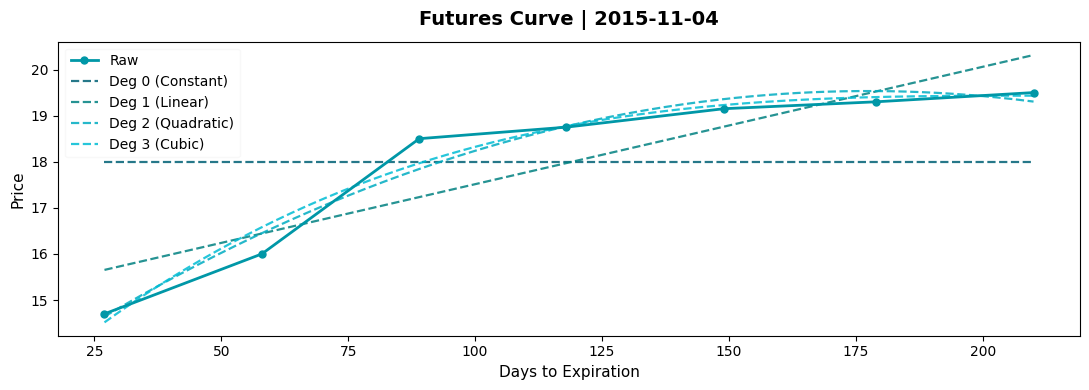

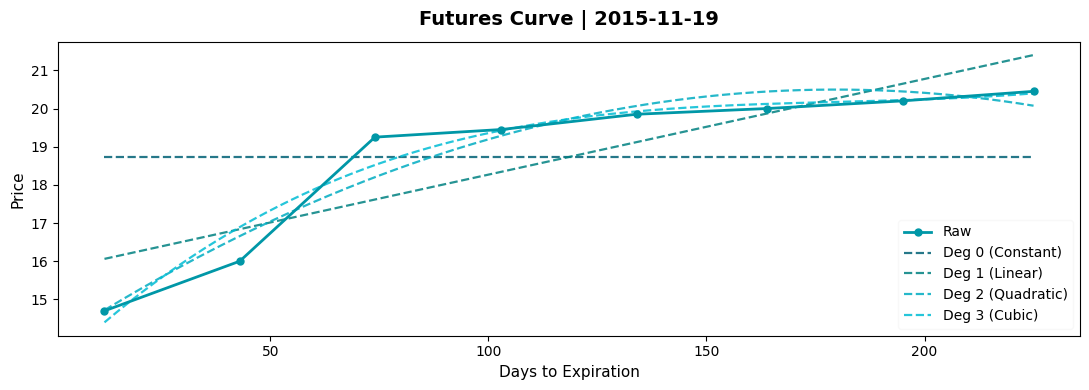

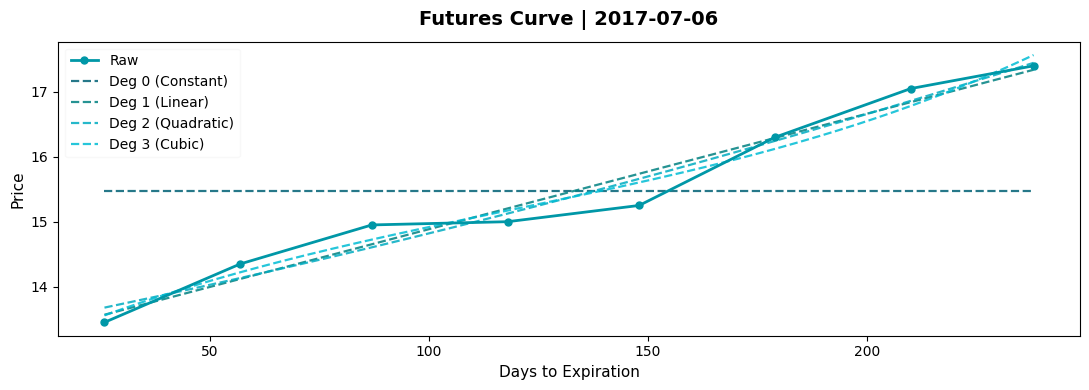

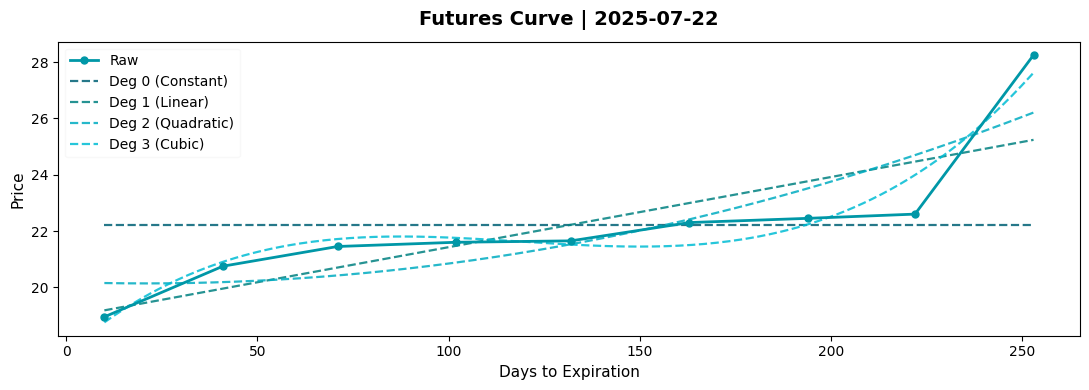

In [10]:
for date in random_dates:
    plot_func.plot_futures_curve(vx_curve_df.loc[date]['price'], vx_curve_df.loc[date]['DTE'], n=3, 
                                 title=f"Futures Curve | {date}", dark=False);

In [13]:
# Adding cols for coefficients

vx_curve_coef = pd.DataFrame()

vx_curve_coef[['twist','curve','slope','intercept']] = vx_curve_df.groupby(vx_curve_df.index).apply(lambda df: pd.Series(np.polyfit(x=df['DTE'], y=df['price'], deg=3)))

C:\Users\dannydavis\AppData\Local\Temp\ipykernel_15228\1335057054.py:5: RankWarning: Polyfit may be poorly conditioned
  vx_curve_coef[['twist','curve','slope','intercept']] = vx_curve_df.groupby(vx_curve_df.index).apply(lambda df: pd.Series(np.polyfit(x=df['DTE'], y=df['price'], deg=3)))
C:\Users\dannydavis\AppData\Local\Temp\ipykernel_15228\1335057054.py:5: RankWarning: Polyfit may be poorly conditioned
  vx_curve_coef[['twist','curve','slope','intercept']] = vx_curve_df.groupby(vx_curve_df.index).apply(lambda df: pd.Series(np.polyfit(x=df['DTE'], y=df['price'], deg=3)))
C:\Users\dannydavis\AppData\Local\Temp\ipykernel_15228\1335057054.py:5: RankWarning: Polyfit may be poorly conditioned
  vx_curve_coef[['twist','curve','slope','intercept']] = vx_curve_df.groupby(vx_curve_df.index).apply(lambda df: pd.Series(np.polyfit(x=df['DTE'], y=df['price'], deg=3)))
C:\Users\dannydavis\AppData\Local\Temp\ipykernel_15228\1335057054.py:5: RankWarning: Polyfit may be poorly conditioned
  vx_curve_

In [14]:
vx_curve_coef

,twist,curve,slope,intercept
date,,,,
2010-01-04,5.450832e-07,-0.000237,0.034681,24.080264
2010-01-05,5.511166e-07,-0.000241,0.036124,23.656875
2010-01-06,7.212220e-07,-0.000320,0.048044,22.759384
2010-01-07,9.393214e-07,-0.000416,0.061634,21.857827
2010-01-08,8.533200e-07,-0.000401,0.064234,21.224939
...,...,...,...,...
2025-12-11,4.840095e-07,-0.000258,0.052040,17.645190
2025-12-12,3.766940e-07,-0.000222,0.048813,17.744508
2025-12-15,4.803176e-07,-0.000258,0.052018,17.781563


##### Creating Fwd Vol Data

In [ ]:
# sp500 = obb_cf.read_file(raw_data_filepath, r"SP500_price_data.parquet")

In [ ]:
# sp500 = obb_cf.append_returns(sp500, 'close')

In [ ]:
# sp500 = obb_cf.append_fwd_vol(sp500, 'simple_return', rolling_period=20)

In [ ]:
# sp500_fwd_vol = sp500[['forward_vol_1m']]
# sp500_fwd_vol.index = pd.to_datetime(sp500_fwd_vol.index)

In [ ]:
# sp500_fwd_vol.to_parquet(os.path.join(raw_data_filepath, r"ForwardVol.parquet"))

##### Analysing with Forward Vol Data

In [46]:
sp500_fwd_vol = obb_cf.read_file(raw_data_filepath, r"ForwardVol.parquet")

In [47]:
sp500_fwd_vol = sp500[['forward_vol_1m']].reset_index()

In [48]:
sp500_fwd_vol

,date,forward_vol_1m
0,2010-01-06,0.191684
1,2010-01-07,0.190948
2,2010-01-08,0.198394
3,2010-01-11,0.197641
4,2010-01-12,0.201262
...,...,...
4017,2025-12-24,NaN
4018,2025-12-26,NaN
4019,2025-12-29,NaN
4020,2025-12-30,NaN


In [22]:
sp500_fwd_vol['date'] = pd.to_datetime(sp500_fwd_vol['date'])

In [23]:
vx_curve_coef = vx_curve_coef.reset_index().merge(sp500_fwd_vol, on='date', how='inner')

In [24]:
vx_curve_coef.dropna(inplace=True)

In [25]:
vx_curve_coef['year'] = vx_curve_coef['date'].dt.year

In [26]:
for i in ['twist', 'curve', 'forward_vol_1m']:
    scaler = StandardScaler()
    x = vx_curve_coef[[i]]
    vx_curve_coef[f"{i}_scaled"] = scaler.fit_transform(X=x)

In [27]:
vx_curve_coef

,date,twist,curve,slope,intercept,forward_vol_1m,year,twist_scaled,curve_scaled,forward_vol_1m_scaled
0,2010-01-06,7.212220e-07,-0.000320,0.048044,22.759384,0.191684,2010,-0.014707,-0.116054,0.460428
1,2010-01-07,9.393214e-07,-0.000416,0.061634,21.857827,0.190948,2010,-0.014154,-0.162262,0.452599
2,2010-01-08,8.533200e-07,-0.000401,0.064234,21.224939,0.198394,2010,-0.014372,-0.154843,0.531826
3,2010-01-11,1.001874e-06,-0.000450,0.068389,20.930088,0.197641,2010,-0.013996,-0.178284,0.523814
4,2010-01-12,1.029651e-06,-0.000439,0.061226,21.842074,0.201262,2010,-0.013925,-0.173100,0.562345
...,...,...,...,...,...,...,...,...,...,...
3876,2025-11-24,5.698350e-07,-0.000286,0.049614,19.577285,0.092904,2025,-0.015090,-0.099976,-0.590591
3877,2025-11-25,3.755378e-07,-0.000227,0.046543,19.144120,0.089013,2025,-0.015582,-0.071460,-0.631993
3878,2025-11-26,3.940413e-07,-0.000239,0.051038,18.591384,0.087830,2025,-0.015535,-0.077448,-0.644580
3879,2025-11-28,5.381791e-07,-0.000292,0.056924,18.187309,0.086381,2025,-0.015170,-0.102623,-0.659999


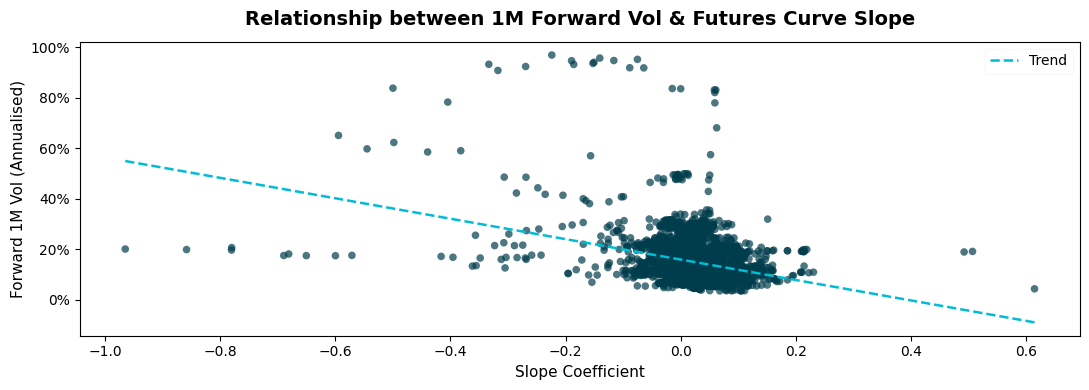

In [33]:
# looking at relationship between slope, curve, and twist with forward vol
plot_func.plot_scatter(vx_curve_coef[vx_curve_coef['date']>'2015'], x='slope', y='forward_vol_1m',
                       title="Relationship between 1M Forward Vol & Futures Curve Slope", figsize=(11,4), dark=False, trend_line=True,
                       percent_y=True, xlabel='Slope Coefficient', ylabel='Forward 1M Vol (Annualised)');

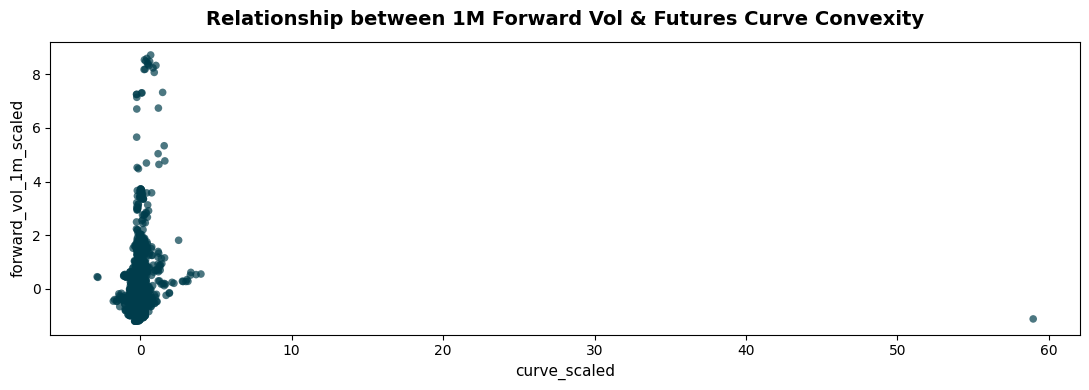

In [29]:
# looking at relationship between slope, curve, and twist with forward vol
plot_func.plot_scatter(vx_curve_coef, x='curve_scaled', y='forward_vol_1m_scaled',
                       title="Relationship between 1M Forward Vol & Futures Curve Convexity", figsize=(11,4), dark=False);

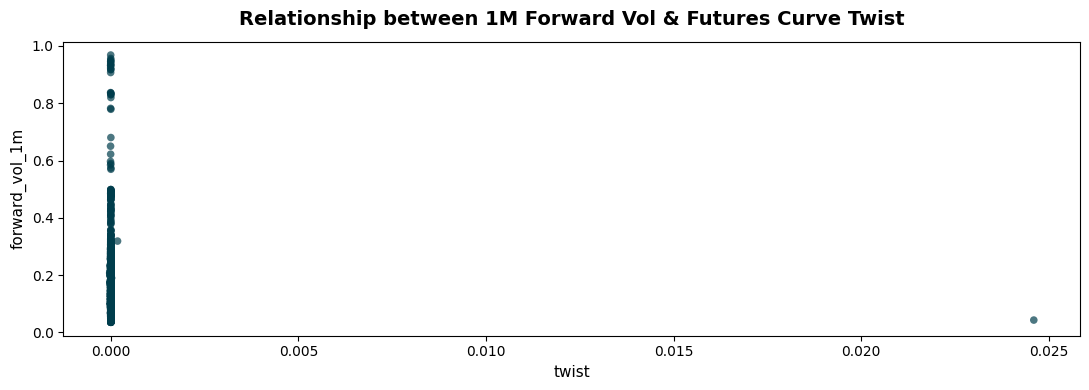

In [30]:
plot_func.plot_scatter(vx_curve_coef, x='twist', y='forward_vol_1m',
                       title="Relationship between 1M Forward Vol & Futures Curve Twist", figsize=(11,4), dark=False);